__DATA PROJECT 1__

__BY: DNYANESHWARI NARHARE__

__Student ID: 018207540__

__INTRODUCTION__

This mini project is a binary classification problem based on readings from helicopter turbine engine sensors, thanks to the PHM North America 2024 Data Challenge. The aim is to classify whether an engine is in working condition or faulty based on some operational parameters. These include outside air temperature, mean gas temperature, indicated airspeed, power available, net power, compressor speed, and measured torque. Engine condition is assessed through a derived parameter referred to as torque margin, underperformance being indicated when the value deviates negatively from design torque. We develop machine learning models based on this background for labeling each engine state as nominal (0) or defective (1). Two classifier algorithms, Random Forest and Logistic Regression, are trained from the training set and their performance evaluated on a test set through measures like precision, recall, F1-score, and ROC AUC. The final goal is to design an adequately generalizable model for unseen engine data with reliable insight toward predictive maintenance.

__Import Libraries__

In [282]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve

__Load data__

In [233]:
x_train = pd.read_csv(r'C:\Users\rushi\Downloads\Data_Challenge_PHM2024_training_data\x_train.csv')
y_train = pd.read_csv(r'C:\Users\rushi\Downloads\Data_Challenge_PHM2024_training_data\y_train.csv')

__Clean column names by stripping extra spaces or characters__

 It removes leading and trailing whitespaces from the column names in both the x_train and y_train DataFrames.

In [235]:
x_train.columns = x_train.columns.str.strip()
y_train.columns = y_train.columns.str.strip()

__Merge features and labels__

Combines both datasets into a single DataFrame df for easier processing.

In [237]:
df = pd.concat([x_train, y_train], axis=1)

__Feature-Label Split__

In supervised machine learning, we train the model to predict labels (y) based on patterns in the features (X). So, this separation is a key preprocessing step.

In [239]:
X = df.drop(columns=['faulty'])  # Features
y = df['faulty']                 # Labels

__Split data into training and testing sets__

In [241]:
X_train, X_test, y_train_split, y_test_split = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

This breaks the dataset into:

80% for training the models

20% for testing them

stratify=y makes sure the ratio of 0s and 1s stays balanced in both sets.

__Scale the data__

Scaling ensures that all features contribute equally to the model, especially those that are sensitive to the magnitude of feature values — like Logistic Regression.

In [243]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

__Logistic Regression Model with scaled data__

In [245]:
log_model = LogisticRegression(max_iter=5000, solver='saga')  
log_model.fit(X_train_scaled, y_train_split)

LogisticRegression(max_iter=5000, solver='saga')

This step is where the model learns the relationship between features (like torque margin, etc.) and the label (faulty or not). Setting the right solver and max_iter helps ensure the model actually converges and performs well.

__Predictions and probabilities__

In [247]:
log_preds = log_model.predict(X_test_scaled)
log_probs = log_model.predict_proba(X_test_scaled)[:, 1]  # Confidence metric

__log_preds__ gives the final predicted labels (0 or 1) for the test data.
__log_probs__ gives the __probability/confidence__ that each sample is faulty (class 1).

These help in evaluating both the classification accuracy and the confidence level of predictions.

__Random Forest Model__

In [249]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train_split)
rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]  # Confidence metric

This model trains a Random Forest classifier with 100 decision trees. It works similarly to logistic regression but uses an ensemble of decision trees for better accuracy and robustness.

__Evaluate models__

In [251]:
print("=== Logistic Regression Report ===")
print(classification_report(y_test_split, log_preds))
print("ROC AUC:", roc_auc_score(y_test_split, log_probs))

print("\n=== Random Forest Report ===")
print(classification_report(y_test_split, rf_preds))
print("ROC AUC:", roc_auc_score(y_test_split, rf_probs))

=== Logistic Regression Report ===
              precision    recall  f1-score   support

           0       0.94      0.96      0.95     88641
           1       0.93      0.90      0.92     59884

    accuracy                           0.94    148525
   macro avg       0.94      0.93      0.93    148525
weighted avg       0.94      0.94      0.94    148525

ROC AUC: 0.9765227116803704

=== Random Forest Report ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     88641
           1       1.00      1.00      1.00     59884

    accuracy                           1.00    148525
   macro avg       1.00      1.00      1.00    148525
weighted avg       1.00      1.00      1.00    148525

ROC AUC: 0.999996730045382


This is responsible for evaluating and comparing the performance of two classification models: __Logistic Regression__ and __Random Forest__. It does this by generating and printing classification reports and ROC AUC scores for each model. The classification_report() function provides a detailed breakdown of key classification metrics including precision, recall, f1-score, and support for each class (0 for nominal and 1 for faulty). These metrics help understand how well each model is performing in identifying faulty and non-faulty cases. Additionally, the roc_auc_score() function computes the Area Under the ROC Curve (AUC), which indicates how well the model is able to distinguish between the two classes. A higher AUC value suggests better model performance. By displaying these results side by side, this section helps the user easily compare the strengths and weaknesses of each model in terms of classification accuracy and confidence.

__ROC Curve comparison__

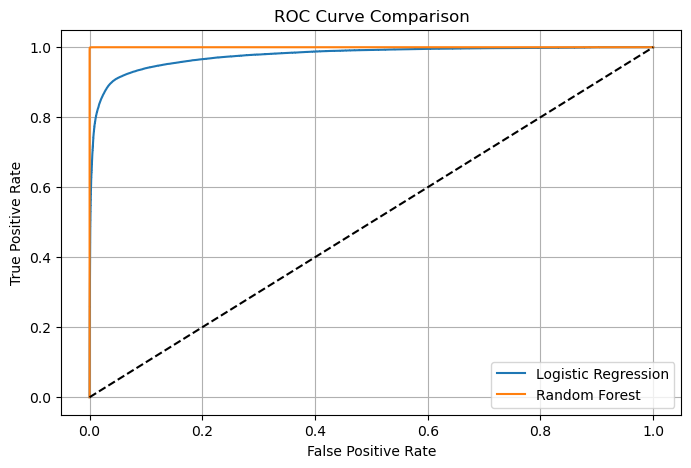

In [253]:
fpr_log, tpr_log, _ = roc_curve(y_test_split, log_probs)
fpr_rf, tpr_rf, _ = roc_curve(y_test_split, rf_probs)

plt.figure(figsize=(8, 5))
plt.plot(fpr_log, tpr_log, label='Logistic Regression')
plt.plot(fpr_rf, tpr_rf, label='Random Forest')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(True)
plt.show()

This part of the code is used to generate and visualize the ROC curves for both the Logistic Regression and Random Forest models, allowing us to compare their performance in distinguishing between the two classes (faulty vs. non-faulty). 

This graph generate a comparison plot of the ROC curves for both the Logistic Regression and Random Forest models. The curve closer to the top-left corner of the plot indicates a better-performing model. The diagonal line (random classifier) serves as a baseline to compare against.

__CONCLUSION__

This code demonstrates a thorough process of evaluating two machine learning models—Logistic Regression and Random Forest—for the classification task of predicting engine health (faulty vs. non-faulty). By splitting the dataset into training and testing sets, scaling the features, and applying both models, the code assesses their performance using various metrics. The classification report provides detailed metrics like precision, recall, and F1-score, giving insight into each model's accuracy and ability to identify faulty and non-faulty cases. The ROC AUC score further quantifies each model's ability to discriminate between the two classes, with higher values indicating better performance. Finally, the ROC curve comparison visualizes the trade-off between the false positive rate and true positive rate for both models. This allows for a clear visual comparison of how well each model performs, with the goal of identifying the model that offers the best balance between correctly identifying faulty engines and minimizing false alarms.

Overall, the analysis provides a comprehensive comparison of the Logistic Regression and Random Forest models, helping guide the choice of the best model for the task at hand.